# Context-distance sweep over HIGH / LOW

Goal: understand how the **baseline-similarity** dimension of the
context design (set by `HIGH` and `LOW`) drives the distance between
contexts A, B, C.  Two metrics, computed on control-cell
log-expression matrices:

1. **Cosine distance between centroids** — captures the mean-shift
   between contexts.
2. **Energy distance between samples** — full-distribution distance
   (captures both mean and dispersion differences).

We reuse the GRN + `context_active_idx` saved by notebook 08; we do
*not* use the gate parameters here — the gate only affects KO
propagation, not control-cell baselines.

Three sweeps:
- 1D over `HIGH` with `LOW` fixed
- 1D over `LOW` with `HIGH` fixed
- 2D heatmap over a grid of `(HIGH, LOW)`

For each grid point we generate per-context control cells via
`ControlDataGenerator.sample_program_activities` +
`generate_expression` (skipping the count-sampling step for speed —
log-expression is the layer downstream analyses operate on anyway).

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.spatial.distance import cdist
from tqdm.auto import tqdm

from GetGOPrograms import GOProgramGenerator
from ControlDataGenerator import ControlDataGenerator

/home/beraslan/miniconda/envs/py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load GRN and context-active-idx

We need the GRN (`W`, `V`, programs) and the per-context active-program
index lists from notebook 08.  `HIGH` / `LOW` saved in the pickle are
the current values — this notebook overrides them in a sweep, so we
discard them.

`ControlDataGenerator` needs a `GOProgramGenerator` instance.  We
rebuild it with the same parameters as notebook 08 (cache hits make
this fast).

In [2]:
DATA_DIR = Path('./DATA')

with open(DATA_DIR / 'grn.pkl', 'rb') as f:
    grn = pickle.load(f)
with open(DATA_DIR / 'context_design.pkl', 'rb') as f:
    design = pickle.load(f)

context_active_idx = design['context_active_idx']
program_names      = design['program_names']
n_programs         = len(program_names)
contexts           = list(context_active_idx)

# Rebuild go_gen so we can instantiate ControlDataGenerator. Parameters
# mirror notebook 08; the GO cache makes this fast.
go_gen = GOProgramGenerator(
    n_programs=15, organism='human', total_genes=5000,
    min_program_size=20, max_program_size=150,
    add_synthetic_program_genes=True,
    n_synthetic_per_program=[30, 80],
    synthetic_overlap_mean=0.85, synthetic_overlap_std=0.05,
    add_filler_genes=True, seed=42,
    data_dir='./go_data', use_cached=True, verbose=False,
)

print(f'n_programs = {n_programs}, n_genes = {grn.n_genes}')
print(f'contexts   = {contexts}')
for c, idx in context_active_idx.items():
    active_names = [program_names[i] for i in sorted(set(idx))]
    print(f'  {c}: {len(active_names):2d} active programs - {active_names}')

Input sequence provided is already in string format. No operation performed


go_data/go-basic.obo: fmt(1.2) rel(2026-01-23) 42,036 Terms


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequen

n_programs = 15, n_genes = 5000
contexts   = ['A', 'B', 'C']
  A: 10 active programs - ['cell_cycle', 'apoptosis', 'dna_repair', 'metabolism', 'ribosome_biogenesis', 'autophagy', 'cell_adhesion', 'er_stress', 'emt', 'chromatin_remodeling']
  B: 10 active programs - ['cell_cycle', 'apoptosis', 'immune_response', 'dna_repair', 'metabolism', 'ribosome_biogenesis', 'oxidative_stress', 'angiogenesis', 'er_stress', 'inflammatory_response']
  C:  8 active programs - ['cell_cycle', 'apoptosis', 'dna_repair', 'oxidative_stress', 'autophagy', 'hypoxia_response', 'inflammatory_response', 'emt']


## Helpers

- `context_logexpr(HIGH, LOW, n_cells, seed)` returns a dict
  `{ctx: (n_cells, n_genes) log-expression matrix}` for all three
  contexts under one `(HIGH, LOW)` pair.
- `cosine_centroid_dist(X, Y)`: 1 - cosine similarity of centroids.
- `energy_distance(X, Y)`: sample energy distance.  Square-rooted form
  is the proper metric; we keep the unrooted form for monotonic
  comparisons.

In [3]:
def build_activity(active_idx, HIGH, LOW, n_programs):
    a = np.full(n_programs, LOW)
    a[list(set(active_idx))] = HIGH
    return a

def context_logexpr(HIGH, LOW, n_cells=200, seed=0, activity_std=0.5):
    """Per-context log-expression matrices under (HIGH, LOW)."""
    ctrl_gen = ControlDataGenerator(grn=grn, go_gen=go_gen, seed=seed)
    out = {}
    for c, idx in context_active_idx.items():
        activity_vec = build_activity(idx, HIGH, LOW, n_programs)
        activities = ctrl_gen.sample_program_activities(
            n_cells=n_cells,
            activity_mean=activity_vec,
            activity_std=activity_std,
            use_correlations=True,
        )
        expr = ctrl_gen.generate_expression(program_activities=activities)
        out[c] = expr
    return out

def cosine_centroid_dist(X, Y):
    cx, cy = X.mean(0), Y.mean(0)
    return float(1.0 - (cx @ cy) / (np.linalg.norm(cx) * np.linalg.norm(cy) + 1e-12))

def energy_distance(X, Y):
    """Sample energy distance squared:  2 E|X-Y| - E|X-X'| - E|Y-Y'|."""
    a = cdist(X, Y).mean()
    b = cdist(X, X).mean()
    c = cdist(Y, Y).mean()
    return float(2.0 * a - b - c)

def pair_distances(ctx_expr):
    """All three pairwise distances for {A,B,C}."""
    pairs = [('A','B'), ('A','C'), ('B','C')]
    rows = []
    for p, q in pairs:
        X, Y = ctx_expr[p], ctx_expr[q]
        rows.append({
            'pair':   f'{p}-{q}',
            'cosine': cosine_centroid_dist(X, Y),
            'energy': energy_distance(X, Y),
        })
    return pd.DataFrame(rows).set_index('pair')

# Quick smoke test
expr_demo = context_logexpr(HIGH=5.0, LOW=-1.0, n_cells=200, seed=0)
print('Per-context log-expression shapes:', {c: x.shape for c, x in expr_demo.items()})
print('\nPair distances at (HIGH=5, LOW=-1):')
print(pair_distances(expr_demo).round(4))

Per-context log-expression shapes: {'A': (200, 5000), 'B': (200, 5000), 'C': (200, 5000)}

Pair distances at (HIGH=5, LOW=-1):
      cosine    energy
pair                  
A-B   0.1437  171.5618
A-C   0.1907  200.7825
B-C   0.1609  179.5968


## 1D sweep over `HIGH` (with `LOW = -1` fixed)

Increasing `HIGH` raises `softplus(HIGH)` ≈ baseline contribution of
active programs, while inactive ones stay flat — so contexts should
separate more as `HIGH` grows.  The relationship saturates because
softplus(x) ≈ x for large x — past `HIGH ≈ 4-5` we expect roughly
linear growth in distance, not exponential.

HIGH sweep: 100%|██████████| 8/8 [00:05<00:00,  1.52it/s]


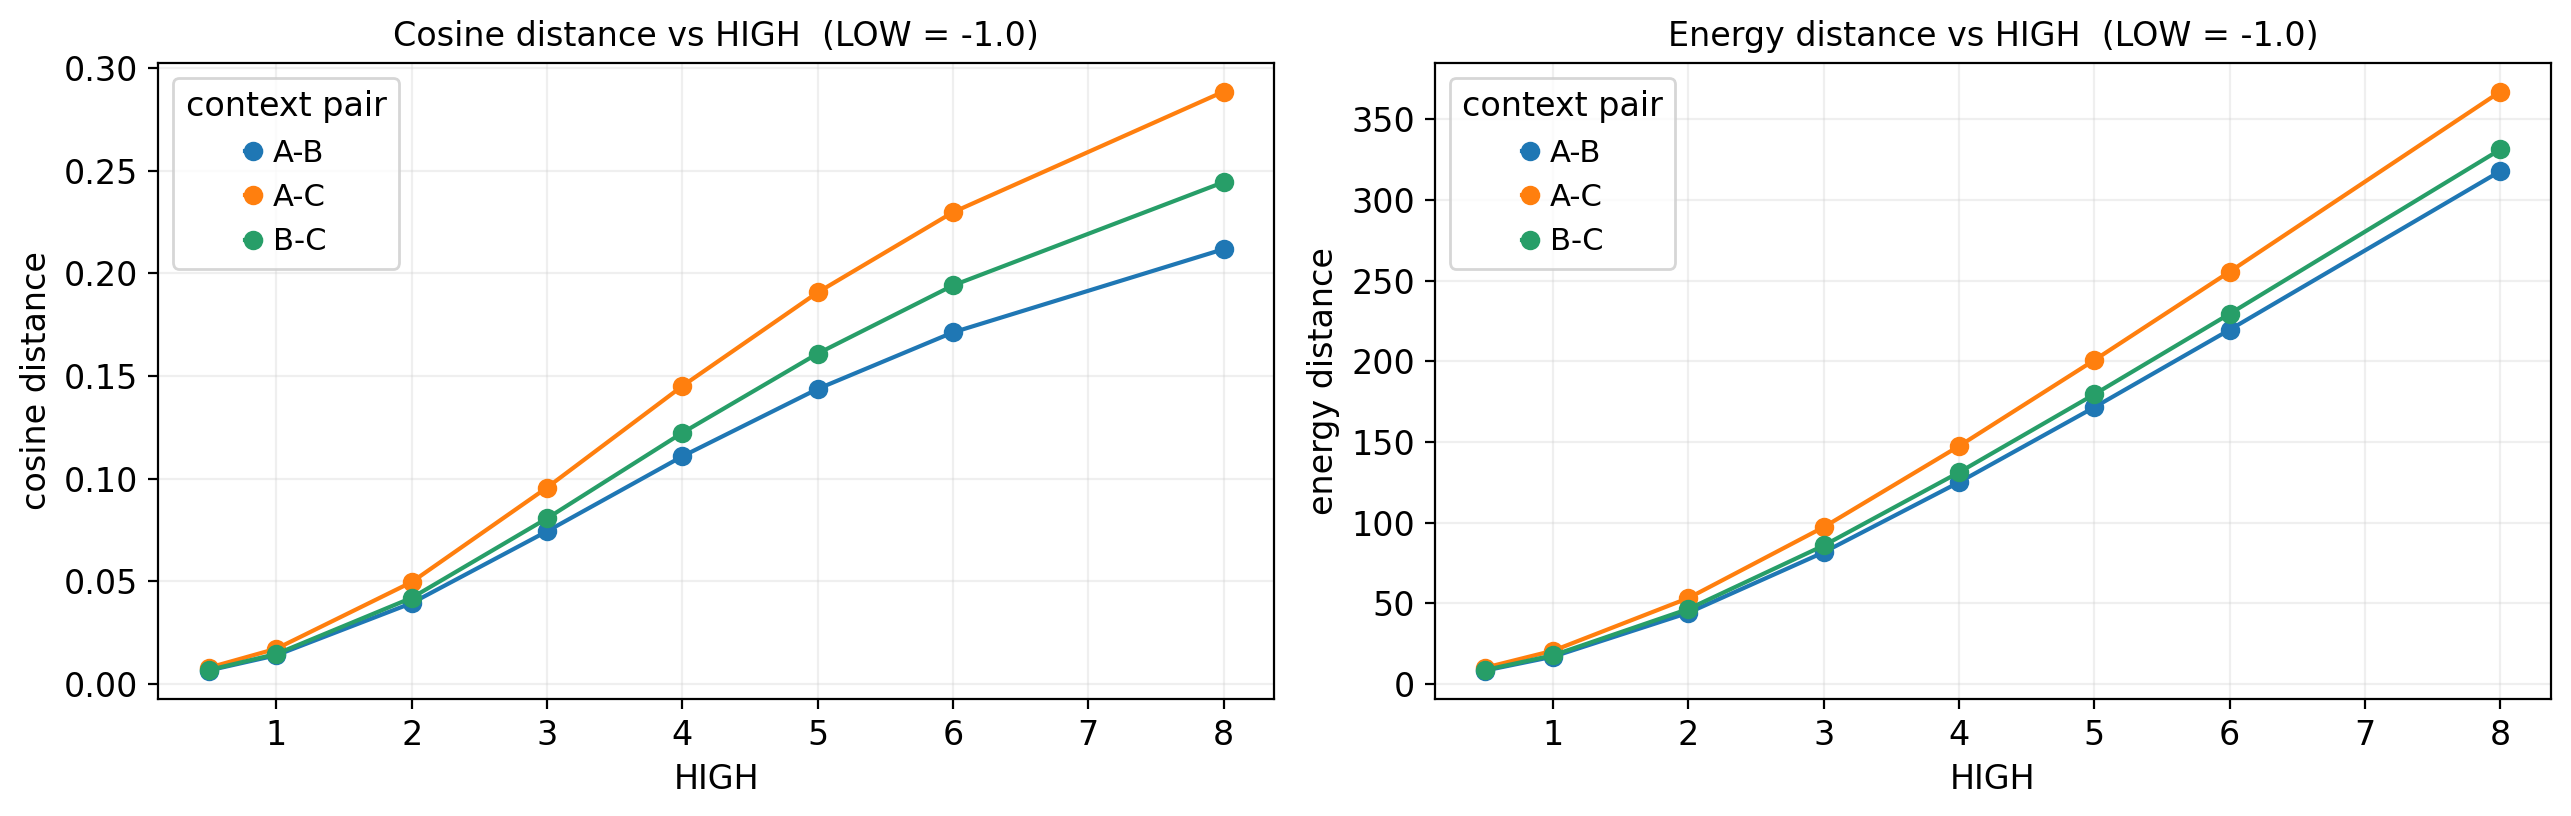

pair     A-B     A-C     B-C
HIGH                        
0.5   0.0065  0.0079  0.0067
1.0   0.0139  0.0171  0.0146
2.0   0.0393  0.0496  0.0419
3.0   0.0743  0.0956  0.0806
4.0   0.1108  0.1450  0.1223
5.0   0.1437  0.1907  0.1609
6.0   0.1712  0.2297  0.1941
8.0   0.2118  0.2885  0.2444


In [4]:
HIGH_VALS = np.array([0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0])
LOW_FIXED = -1.0

records = []
for H in tqdm(HIGH_VALS, desc='HIGH sweep'):
    expr = context_logexpr(HIGH=float(H), LOW=LOW_FIXED, n_cells=200, seed=0)
    dists = pair_distances(expr)
    for pair, row in dists.iterrows():
        records.append({'HIGH': float(H), 'pair': pair,
                        'cosine': row['cosine'], 'energy': row['energy']})
df_high = pd.DataFrame(records)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for metric, ax in zip(['cosine', 'energy'], axes):
    for pair, sub in df_high.groupby('pair'):
        ax.plot(sub['HIGH'], sub[metric], '-o', label=pair, lw=1.5)
    ax.set_xlabel('HIGH'); ax.set_ylabel(f'{metric} distance')
    ax.set_title(f'{metric.capitalize()} distance vs HIGH  (LOW = {LOW_FIXED})')
    ax.grid(alpha=0.3); ax.legend(title='context pair')
plt.tight_layout(); plt.show()

print(df_high.pivot(index='HIGH', columns='pair', values='cosine').round(4))

## 1D sweep over `LOW` (with `HIGH = 5` fixed)

Lowering `LOW` (more negative) drives `softplus(LOW) → 0`, so
inactive programs contribute less to baseline — separation grows.  As
`LOW → 0`, contexts converge.  `LOW > 0` would saturate the difference
in the opposite direction (active and inactive both contribute, just
differently scaled).

LOW sweep: 100%|██████████| 8/8 [00:05<00:00,  1.51it/s]


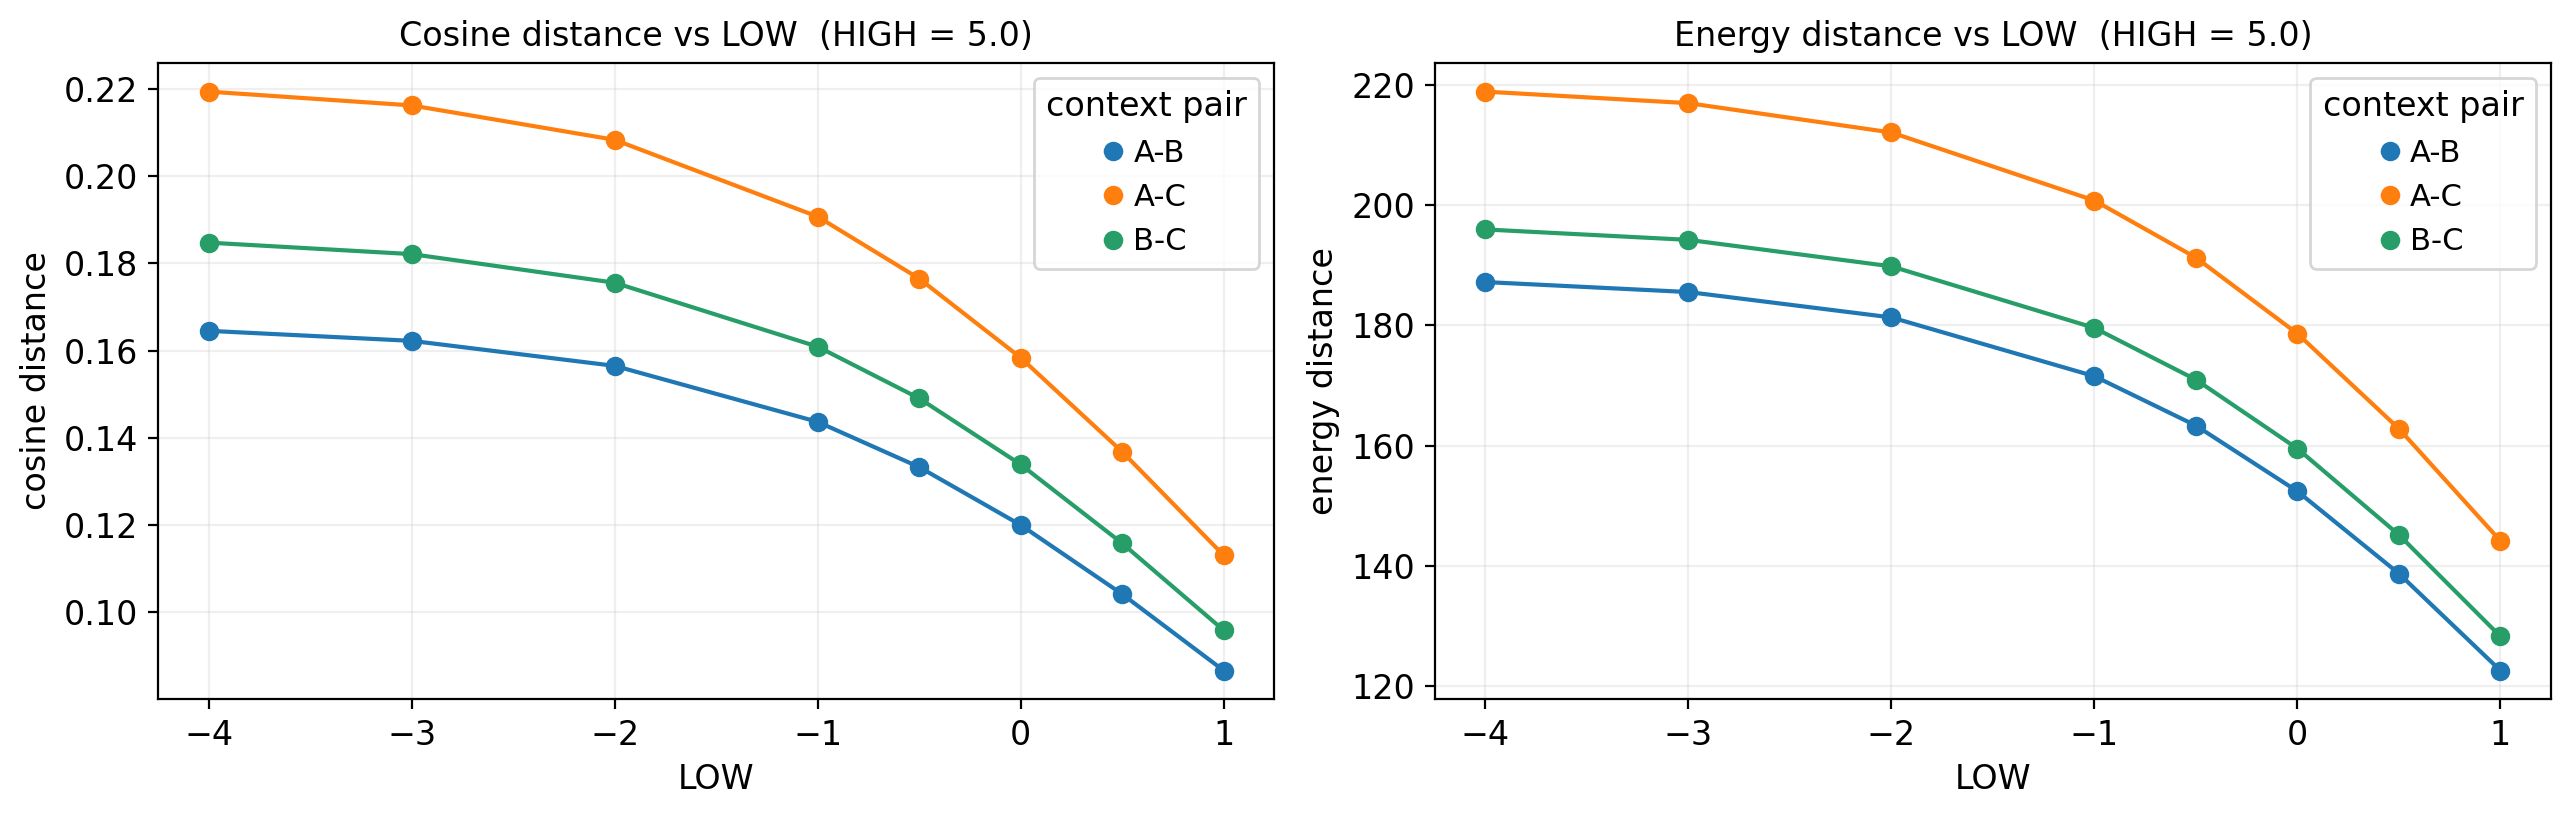

pair     A-B     A-C     B-C
LOW                         
-4.0  0.1645  0.2193  0.1847
-3.0  0.1622  0.2162  0.1821
-2.0  0.1565  0.2083  0.1755
-1.0  0.1437  0.1907  0.1609
-0.5  0.1333  0.1765  0.1491
 0.0  0.1200  0.1584  0.1339
 0.5  0.1042  0.1368  0.1158
 1.0  0.0867  0.1131  0.0959


In [5]:
LOW_VALS = np.array([-4.0, -3.0, -2.0, -1.0, -0.5, 0.0, 0.5, 1.0])
HIGH_FIXED = 5.0

records = []
for L in tqdm(LOW_VALS, desc='LOW sweep'):
    expr = context_logexpr(HIGH=HIGH_FIXED, LOW=float(L), n_cells=200, seed=0)
    dists = pair_distances(expr)
    for pair, row in dists.iterrows():
        records.append({'LOW': float(L), 'pair': pair,
                        'cosine': row['cosine'], 'energy': row['energy']})
df_low = pd.DataFrame(records)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for metric, ax in zip(['cosine', 'energy'], axes):
    for pair, sub in df_low.groupby('pair'):
        ax.plot(sub['LOW'], sub[metric], '-o', label=pair, lw=1.5)
    ax.set_xlabel('LOW'); ax.set_ylabel(f'{metric} distance')
    ax.set_title(f'{metric.capitalize()} distance vs LOW  (HIGH = {HIGH_FIXED})')
    ax.grid(alpha=0.3); ax.legend(title='context pair')
plt.tight_layout(); plt.show()

print(df_low.pivot(index='LOW', columns='pair', values='cosine').round(4))

## Collapse to a single parameter: `Δ = softplus(HIGH) − softplus(LOW)`

The per-program baseline contribution is `softplus(activity) · W[:, p]`,
so two contexts differ on a program iff their `softplus(activity)`
values differ.  If the design overlap is held fixed (it is: same
`context_active_idx` everywhere), pairwise distance should scale
primarily with `Δ`.  Combine the two 1D sweeps and plot vs `Δ`.

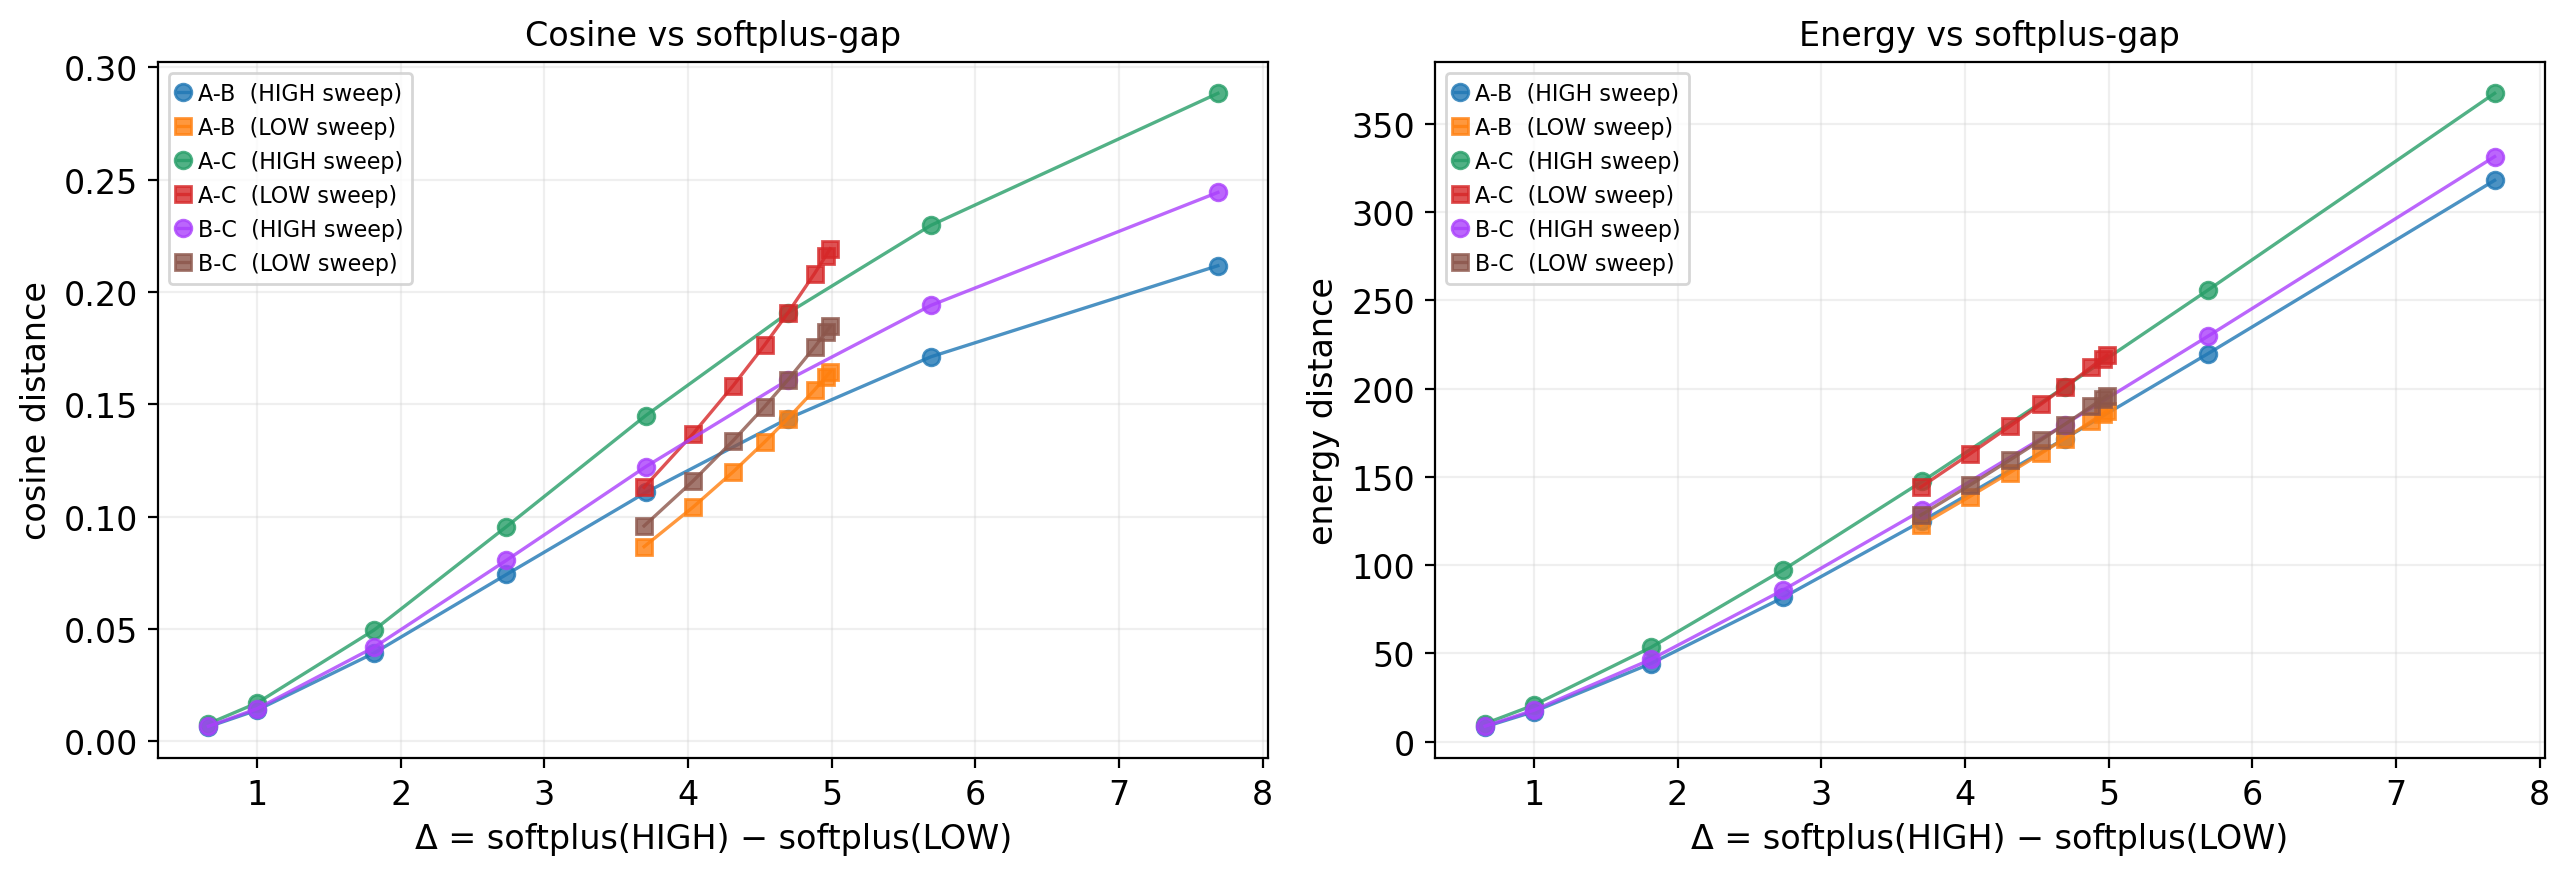

In [6]:
softplus = lambda x: np.log1p(np.exp(x))
df_high['delta'] = softplus(df_high['HIGH']) - softplus(LOW_FIXED)
df_low['delta']  = softplus(HIGH_FIXED) - softplus(df_low['LOW'])
df_high['sweep'] = 'HIGH sweep'
df_low['sweep']  = 'LOW sweep'
df_collapsed = pd.concat([df_high, df_low], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for metric, ax in zip(['cosine', 'energy'], axes):
    for (pair, sweep), sub in df_collapsed.groupby(['pair', 'sweep']):
        marker = 'o' if sweep == 'HIGH sweep' else 's'
        ax.plot(sub['delta'], sub[metric], marker=marker,
                ls='-', alpha=0.8, label=f'{pair}  ({sweep})', lw=1.2)
    ax.set_xlabel('Δ = softplus(HIGH) − softplus(LOW)')
    ax.set_ylabel(f'{metric} distance')
    ax.set_title(f'{metric.capitalize()} vs softplus-gap')
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 2D grid over `(HIGH, LOW)`

Average cosine distance across the three pairs, as a heatmap.  Useful
for picking a `(HIGH, LOW)` that puts the contexts at a desired level
of separation.

HIGH: 100%|██████████| 6/6 [00:23<00:00,  3.95s/it]


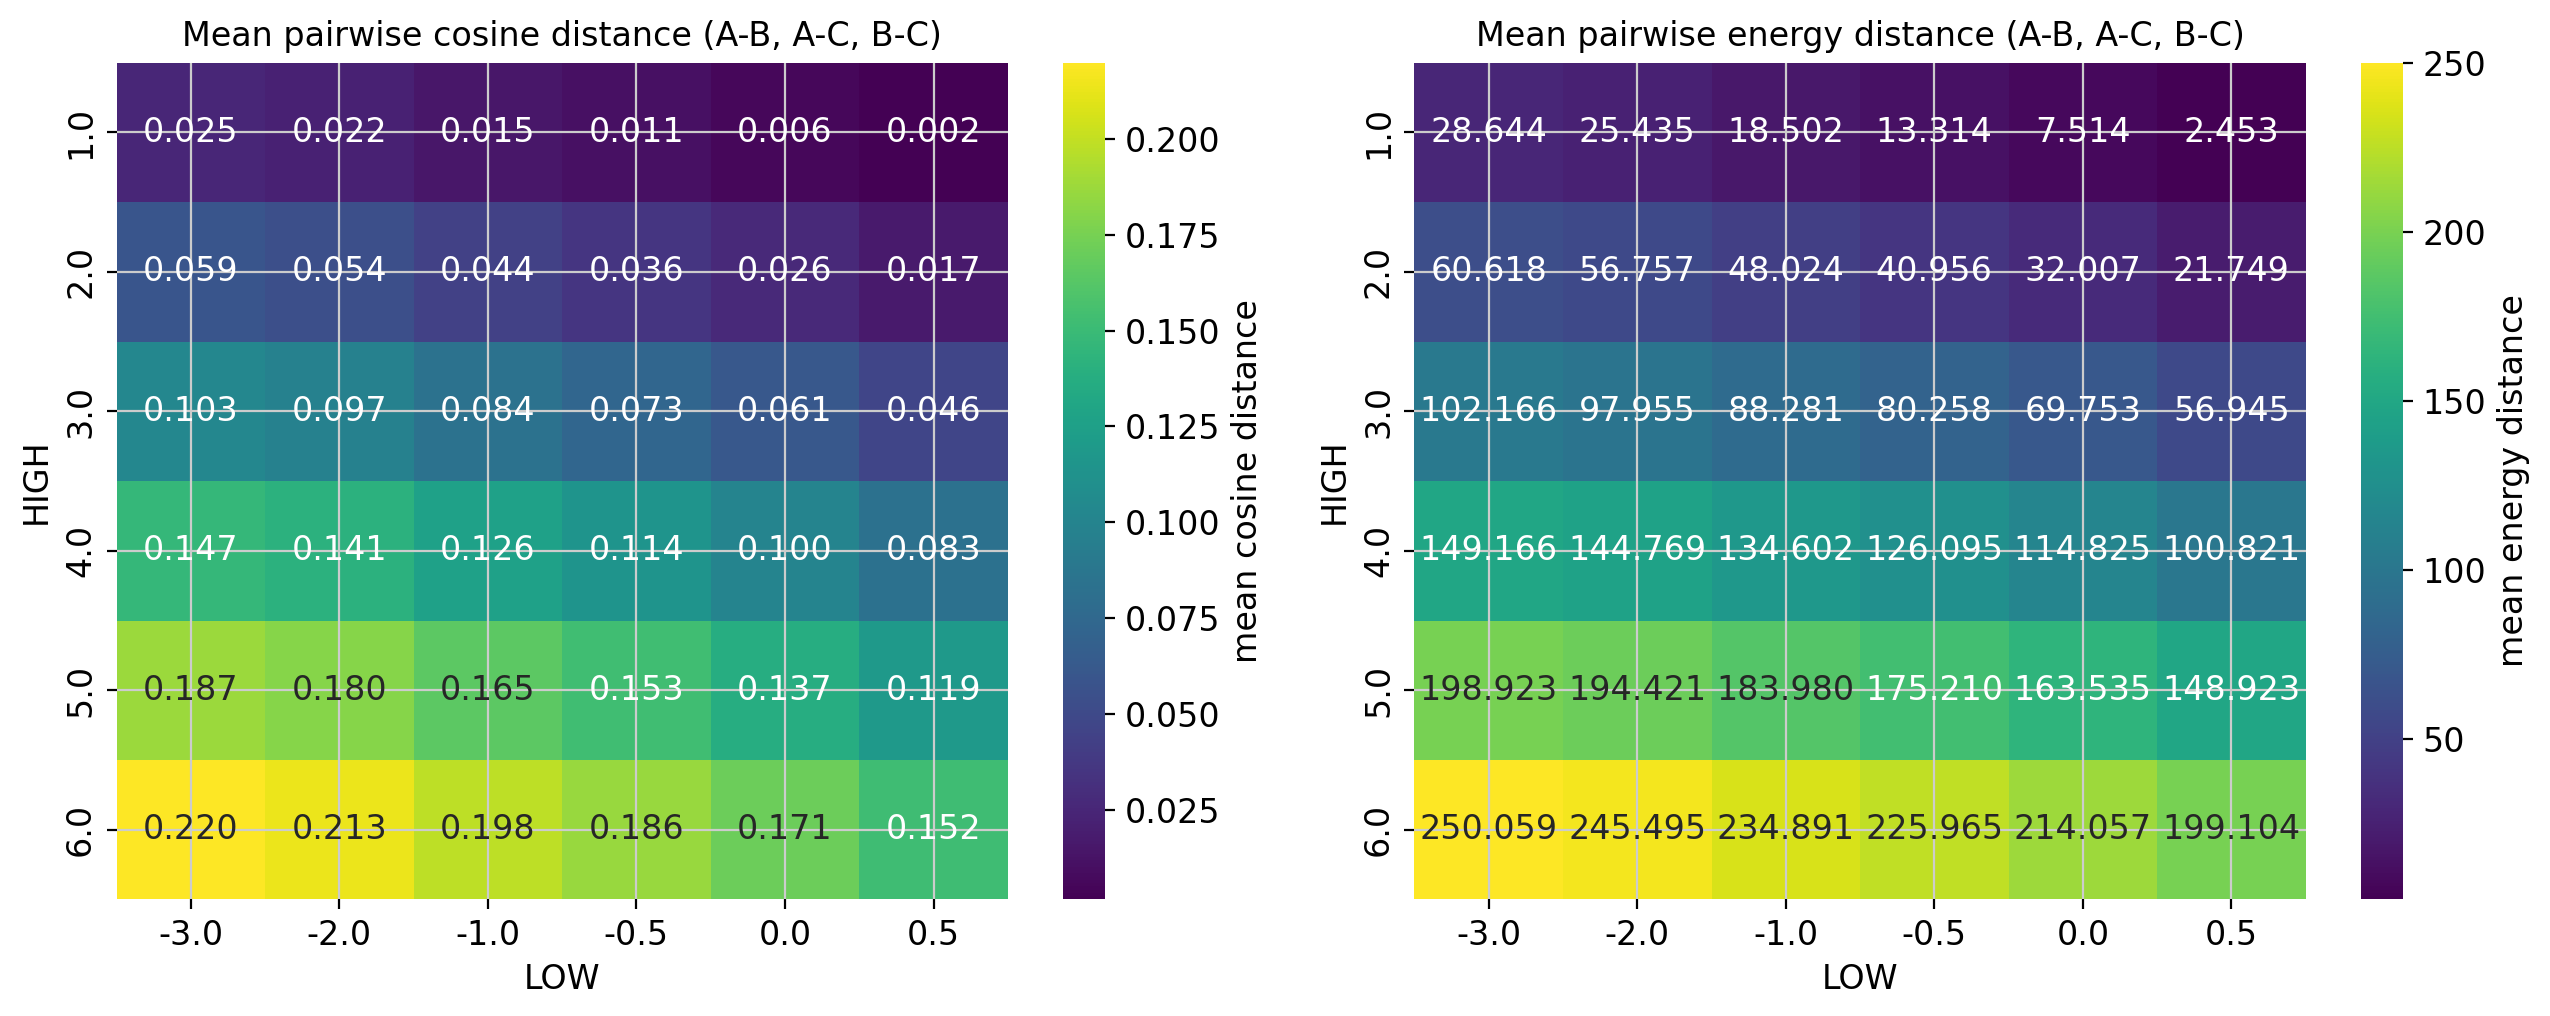

In [7]:
HIGH_GRID = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0])
LOW_GRID  = np.array([-3.0, -2.0, -1.0, -0.5, 0.0, 0.5])

cos_grid = np.full((len(HIGH_GRID), len(LOW_GRID)), np.nan)
en_grid  = np.full((len(HIGH_GRID), len(LOW_GRID)), np.nan)

for i, H in enumerate(tqdm(HIGH_GRID, desc='HIGH')):
    for j, L in enumerate(LOW_GRID):
        if L >= H:        # nonsensical when LOW ≥ HIGH
            continue
        expr = context_logexpr(HIGH=float(H), LOW=float(L), n_cells=200, seed=0)
        dists = pair_distances(expr)
        cos_grid[i, j] = dists['cosine'].mean()
        en_grid[i, j]  = dists['energy'].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
for metric, mat, ax in zip(['cosine', 'energy'], [cos_grid, en_grid], axes):
    sns.heatmap(
        pd.DataFrame(mat, index=HIGH_GRID, columns=LOW_GRID),
        annot=True, fmt='.3f', cmap='viridis', ax=ax,
        cbar_kws={'label': f'mean {metric} distance'},
    )
    ax.set_xlabel('LOW'); ax.set_ylabel('HIGH')
    ax.set_title(f'Mean pairwise {metric} distance (A-B, A-C, B-C)')
plt.tight_layout(); plt.show()

## Takeaway — picking `HIGH` / `LOW`

- **Distances are monotone in `softplus(HIGH) − softplus(LOW)`** — the
  curves from the two 1D sweeps collapse onto a single trend in the
  `Δ` plot.  So once you know the target context separation, any
  `(HIGH, LOW)` pair achieving that `Δ` is equivalent for baseline
  distance.
- **`HIGH` past ~5 buys diminishing returns** because
  `softplus(HIGH) ≈ HIGH` and the separation grows linearly with
  `HIGH`, but downstream count-sampling truncates the long tail.
- **`LOW` doing the work**: pushing `LOW` from -1 → -3 noticeably
  increases separation (because `softplus(-3) ≈ 0.05` vs
  `softplus(-1) ≈ 0.31`).  Past `LOW ≈ -3` the gains diminish.
- **Pair-specific structure**: A-B vs B-C vs A-C distances differ
  according to how many programs they share via `context_active_idx`
  — `Δ` scales them all together, but the prefactor is set by the
  symmetric-difference of their active-program sets.

If you want concrete targets:

| Goal | Try |
|---|---|
| contexts barely distinguishable | `HIGH=2, LOW=0` |
| moderate separation (current) | `HIGH=5, LOW=-1` |
| strong separation (cell-type-like) | `HIGH=6, LOW=-3` |

Once `HIGH`/`LOW` are chosen, the **gate** (`sigmoid_threshold`,
`sigmoid_scale`) controls how much KO effect propagates in inactive
contexts — that's the next dimension to sweep.